# Where is EAT Dice actually lost, and does 2.5D context fix it?

**Scratch / diagnostic notebook — untracked, safe to delete.**

Volume Dice decomposes *exactly* into a per-slice weighted mean — no assumptions:

$$\mathrm{Dice}_{\text{vol}} \;=\; \sum_i w_i\,d_i,\qquad
w_i=\frac{p_i+g_i}{\sum_j (p_j+g_j)},\qquad
d_i=\frac{2\,|P_i\cap G_i|}{p_i+g_i}$$

and since $2|P_i \cap G_i| = p_i + g_i - \mathrm{FP}_i - \mathrm{FN}_i$, the *shortfall*
decomposes just as exactly:

$$1-\mathrm{Dice}_{\text{vol}} \;=\; \sum_i w_i(1-d_i) \;=\; \sum_i \frac{\mathrm{FP}_i+\mathrm{FN}_i}{\sum_j (p_j+g_j)}$$

So every slice gets an attributable, additive share of the Dice deficit, split into a
false-positive and a false-negative half. Everything below is that identity, checked
against the numbers already recorded in each run's `val_metrics_per_patient.csv`.

## ⚠️ Corrected 2026-09-06 — the original comparison was confounded

This notebook originally compared `both_baseline_dice_ce` against `both_ctx_cs3` and read
the difference as the effect of 2.5D context. Those two runs differ in **two** things:
`context_slices` (0 → 3) *and* `augment` (`False` → `True`). The config check below
asserted on eight keys but not on `augment`, so the confound passed silently.

The config-matched control for the context runs is **`both_data_aug_dice_ce`**
(`augment=True, context_slices=0`). Against it, context does essentially nothing to EAT —
see §0 below. All three arms are now carried through, so the two factors are separated
instead of pooled:

| arm | run | `augment` | `context_slices` |
|---|---|---|---|
| `baseline` | `both_baseline_dice_ce` | `False` | 0 |
| `aug` (**control**) | `both_data_aug_dice_ce` | `True` | 0 |
| `cs3` (**treatment**) | `both_ctx_cs3` | `True` | 3 |

`aug` → `cs3` is the one clean single-factor contrast. `baseline` → `aug` is the
augmentation effect, carried so the previously-reported `baseline` → `cs3` gain can be
split into its two parts rather than credited entirely to context.

### Cases

All arms use `split_seed=0` and identical folds, so each patient sits in the same
validation fold in all three runs — a clean paired comparison. Held-out **test** patients
are in no fold and are never touched here.

The two cases are **the two lowest-EAT patients under the control arm**. That criterion is
deliberately independent of the contrast being tested: picking the patient where context
helped most would be selecting on the outcome, and against a null cohort effect that
selects noise.

| patient | baseline | aug | cs3 | aug → cs3 | HD95 aug | HD95 cs3 | why this case |
|---|---|---|---|---|---|---|---|
| `CADRE_1875` | 0.6765 | 0.6880 | 0.6795 | **−0.0085** | 9.46 mm | 10.20 mm | worst EAT in the cohort; context makes it slightly *worse* |
| `CADRE_1851` | 0.6408 | 0.7010 | 0.7379 | **+0.0369** | 6.37 mm | 4.00 mm | 2nd worst; the largest context gain in the cohort |

Between them they bracket the entire range of the context effect (−0.029 … +0.037), whose
cohort mean is −0.0004. Of `CADRE_1851`'s +0.097 `baseline` → `cs3` gain — originally
attributed to context in full — **+0.060 is augmentation and +0.037 is context**.

In [1]:
import json, csv, sys, glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import binary_dilation, generate_binary_structure
from scipy.stats import wilcoxon

REPO = Path.cwd()
assert (REPO / 'train.py').exists(), f'run this notebook from the repo root, not {REPO}'
sys.path.insert(0, str(REPO))

from unet import UNet
from utils.data_loading import VolumeMRIDataset
from utils import metrics
from train import n_channels_for, BOTH_CLASS_NAMES, dir_img, dir_mask

EAT_CLS   = 5
CLASS_LBL = {0: 'background', **BOTH_CLASS_NAMES}          # 0..5

# Each arm declares the config it is SUPPOSED to have, and the next-but-one cell asserts
# the run on disk actually matches. Declaring the factors is what keeps a second variable
# from riding along unnoticed: the first version of this notebook compared `baseline` with
# `cs3` and credited the difference to context, but those runs also differ in `augment`.
ARMS = {
    'baseline': dict(run='both_baseline_dice_ce', augment=False, context_slices=0),
    'aug':      dict(run='both_data_aug_dice_ce', augment=True,  context_slices=0),
    'cs3':      dict(run='both_ctx_cs3',          augment=True,  context_slices=3),
}
FACTORS = ('augment', 'context_slices')     # everything else must match across arms
CONTROL, TREATMENT = 'aug', 'cs3'           # the one clean single-factor contrast

PATIENTS = ['CADRE_1851', 'CADRE_1875']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '| classes:', CLASS_LBL)

/hpc/jgeo610/Virtual_ENV/unet_env/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cuda | classes: {0: 'background', 1: 'LV', 2: 'RV', 3: 'LA', 4: 'RA', 5: 'EAT'}


In [2]:
# --- plot style -------------------------------------------------------------
# Categorical slots from the validated reference palette (light mode).
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
C_MAGENTA, C_GREEN, C_VIOLET, C_RED = '#e87ba4', '#008300', '#4a3aa7', '#e34948'
SURFACE, INK, INK_2, INK_MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#8a8880'

# colour follows the arm, never its rank
ARM_COLOR = {'baseline': C_BLUE, 'aug': C_GREEN, 'cs3': C_ORANGE}
FN_COLOR, FP_COLOR = C_BLUE, C_ORANGE               # under- vs over-segmentation

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': INK_MUTED, 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelcolor': INK_2, 'axes.titlecolor': INK, 'axes.titlesize': 11,
    'axes.titleweight': 'semibold', 'axes.titlelocation': 'left', 'axes.titlepad': 20,
    'text.color': INK, 'xtick.color': INK_2, 'ytick.color': INK_2,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'axes.labelsize': 9.5,
    'grid.color': '#e6e5e1', 'grid.linewidth': 0.7, 'axes.grid': True, 'axes.axisbelow': True,
    'legend.frameon': False, 'legend.fontsize': 9, 'font.size': 10,
    'lines.linewidth': 2.0, 'figure.dpi': 110,
})

def subtitle(ax, text):
    ax.text(0.0, 1.004, text, transform=ax.transAxes, ha='left', va='bottom',
            fontsize=8.5, color=INK_2)

In [3]:
# --- locate, for each patient, the fold in which it was a VALIDATION case ----
def fold_configs(run_prefix):
    out = {}
    for p in sorted(glob.glob(f'checkpoints/{run_prefix}_kfold*/run_config.json')):
        cfg = json.load(open(p))
        cfg['_dir'] = Path(p).parent
        out[cfg['fold']] = cfg
    return out

CFGS = {arm: fold_configs(spec['run']) for arm, spec in ARMS.items()}
for arm, cfgs in CFGS.items():
    assert cfgs, f'{arm}: no run_config.json under checkpoints/{ARMS[arm]["run"]}_kfold*'

FOLD_OF = {}
for pid in PATIENTS:
    folds = {arm: [f for f, c in cfgs.items() if pid in c['val_patients']]
             for arm, cfgs in CFGS.items()}
    assert all(len(v) == 1 for v in folds.values()), f'{pid}: not a val patient exactly once: {folds}'
    assert len({v[0] for v in folds.values()}) == 1, f'{pid}: arms disagree on fold: {folds}'
    FOLD_OF[pid] = folds[CONTROL][0]

# Every arm must be the same experiment apart from the factors it declares. Asserting the
# DECLARED factors -- rather than just "these particular keys happen to match" -- is what
# makes a hidden second difference impossible: each arm must really have the factor values
# it claims, and every other key must be equal across all arms. The original version of
# this cell listed eight keys to compare and `augment` was not one of them.
SHARED = ('split_seed', 'phase', 'img_scale', 'n_classes', 'loss', 'k_folds', 'epochs',
          'batch_size', 'seed', 'arch', 'lr', 'lr_schedule', 'select_on',
          'val_patients', 'test_patients')

for pid, fold in FOLD_OF.items():
    ref = CFGS[CONTROL][fold]
    for arm, spec in ARMS.items():
        c = CFGS[arm][fold]
        for k in FACTORS:
            assert c[k] == spec[k], f'{arm} fold {fold}: declared {k}={spec[k]}, run has {c[k]}'
        for k in SHARED:
            assert c.get(k) == ref.get(k), \
                f'fold {fold}: {arm} differs from {CONTROL} on {k} ({c.get(k)} vs {ref.get(k)})'
        assert pid not in c['test_patients'], f'{pid} is a TEST patient — do not score it here'

# ...and the headline contrast must vary exactly one factor
differing = [k for k in FACTORS if ARMS[CONTROL][k] != ARMS[TREATMENT][k]]
assert differing == ['context_slices'], f'{CONTROL} vs {TREATMENT} differ on {differing}'

for pid, fold in FOLD_OF.items():
    print(f'{pid}: fold {fold}')
    for arm in ARMS:
        c = CFGS[arm][fold]
        print(f'    {arm:<9} {c["_dir"].name:<28} '
              f'augment={c["augment"]!s:<5} context_slices={c["context_slices"]}')
print(f'\nheadline contrast: {CONTROL} -> {TREATMENT}, differing only in {differing[0]}')

CADRE_1851: fold 4
    baseline  both_baseline_dice_ce_kfold4 augment=False context_slices=0
    aug       both_data_aug_dice_ce_kfold4 augment=True  context_slices=0
    cs3       both_ctx_cs3_kfold4          augment=True  context_slices=3
CADRE_1875: fold 0
    baseline  both_baseline_dice_ce_kfold0 augment=False context_slices=0
    aug       both_data_aug_dice_ce_kfold0 augment=True  context_slices=0
    cs3       both_ctx_cs3_kfold0          augment=True  context_slices=3

headline contrast: aug -> cs3, differing only in context_slices


In [4]:
# --- model + dataset loading (both cached; the two datasets share the disk cache) ---
_datasets, _models = {}, {}

def get_dataset(cfg):
    key = (cfg['context_slices'], cfg['img_scale'])
    if key not in _datasets:
        _datasets[key] = VolumeMRIDataset(dir_img, dir_mask, scale=cfg['img_scale'],
                                          phase=cfg['phase'], context_slices=cfg['context_slices'])
    return _datasets[key]

def get_model(cfg):
    key = str(cfg['_dir'])
    if key not in _models:
        net = UNet(n_channels=n_channels_for(cfg['phase'], cfg['context_slices']),
                   n_classes=cfg['n_classes'], bilinear=cfg['bilinear'])
        sd = torch.load(cfg['_dir'] / 'best.pth', map_location='cpu')
        sd.pop('mask_values', None)          # train.py injects this; load_state_dict would choke
        net.load_state_dict(sd)
        _models[key] = net.to(device).eval()
    return _models[key]

def patient_indices(dataset, pid):
    return [i for i, (p, _) in enumerate(dataset.index) if p == pid]

In [5]:
# --- the decomposition ------------------------------------------------------
def decompose(pred_vol, gt_vol, cls=EAT_CLS):
    # exact additive attribution of volume Dice (and its deficit) to slices
    g = (gt_vol == cls)
    p = (pred_vol == cls)
    flat = lambda v: v.reshape(v.shape[0], -1).sum(1).astype(np.float64)

    g_i, p_i = flat(g), flat(p)
    inter_i  = flat(g & p)
    fp_i     = flat(p & ~g)
    fn_i     = flat(g & ~p)

    D = (p_i + g_i).sum()
    with np.errstate(invalid='ignore', divide='ignore'):
        d_i = np.where(p_i + g_i > 0, 2 * inter_i / (p_i + g_i), np.nan)

    out = dict(gt=g_i, pred=p_i, inter=inter_i, fp=fp_i, fn=fn_i,
               w=(p_i + g_i) / D,
               dice_slice=d_i,
               deficit_fp=fp_i / D, deficit_fn=fn_i / D,
               deficit=(fp_i + fn_i) / D,
               dice_vol=2 * inter_i.sum() / D)

    # the identity is the whole point -- verify it rather than assume it
    assert np.isclose(np.nansum(out['w'] * np.nan_to_num(d_i)), out['dice_vol'])
    assert np.isclose(out['deficit'].sum(), 1 - out['dice_vol'])
    return out


def error_attribution(pred_vol, gt_vol, cls=EAT_CLS):
    # what EAT false positives really are, and what its false negatives became
    g, p = gt_vol == cls, pred_vol == cls
    fp, fn = p & ~g, g & ~p
    n = int(gt_vol.max()) + 1
    return {
        'fp_true_label':  np.bincount(gt_vol[fp].ravel(),   minlength=n).astype(float),
        'fn_pred_label':  np.bincount(pred_vol[fn].ravel(), minlength=n).astype(float),
    }


def rim_vs_detached(pred_vol, gt_vol, cls=EAT_CLS):
    # Split error voxels into boundary jitter around correct EAT vs errors away from it.
    #
    # EAT is thin and diffuse, so it has a very large perimeter-to-volume ratio: a
    # substantial share of its deficit is one-voxel rim disagreement that no
    # architecture change recovers. Errors NOT touching a correct EAT voxel are the
    # genuinely fixable part -- missed regions and hallucinations.
    g, p = gt_vol == cls, pred_vol == cls
    tp = g & p
    near = binary_dilation(tp, structure=generate_binary_structure(3, 1), iterations=1)
    err = (p & ~g) | (g & ~p)
    n_err = int(err.sum())
    return {'rim': int((err & near).sum()), 'detached': int((err & ~near).sum()), 'total': n_err}

In [6]:
# --- run both arms on both patients ----------------------------------------
R = {}   # (patient, arm) -> everything

for pid in PATIENTS:
    fold = FOLD_OF[pid]
    gt_ref = None
    for arm in ARMS:
        cfg = CFGS[arm][fold]
        ds  = get_dataset(cfg)
        net = get_model(cfg)
        idxs = patient_indices(ds, pid)
        pred_vol, gt_vol, ent = metrics.predict_volume(
            net, ds, idxs, device, amp=False, batch_size=8, return_entropy=True)

        if gt_ref is None:
            gt_ref = gt_vol
        else:
            assert np.array_equal(gt_ref, gt_vol), 'arms disagree on ground truth — not comparable'

        rec = decompose(pred_vol, gt_vol)
        rec.update(pred_vol=pred_vol, gt_vol=gt_vol, entropy=ent,
                   attribution=error_attribution(pred_vol, gt_vol),
                   rim=rim_vs_detached(pred_vol, gt_vol),
                   cfg=cfg, dataset=ds, indices=sorted(idxs, key=lambda i: ds.index[i][1]))
        R[(pid, arm)] = rec
        print(f'{pid:<14} {arm:<9} {pred_vol.shape[0]:>3} slices  volume Dice {rec["dice_vol"]:.4f}')

/tmp/ipykernel_6356/3767430556.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(cfg['_dir'] / 'best.pth', map_location='cpu')


CADRE_1851     baseline  100 slices  volume Dice 0.6408


CADRE_1851     aug       100 slices  volume Dice 0.7011


CADRE_1851     cs3       100 slices  volume Dice 0.7378


CADRE_1875     baseline   90 slices  volume Dice 0.6767


CADRE_1875     aug        90 slices  volume Dice 0.6880


CADRE_1875     cs3        90 slices  volume Dice 0.6795


In [7]:
# --- verify against the numbers already on disk -----------------------------
def recorded(arm, fold, pid, cls=EAT_CLS):
    path = CFGS[arm][fold]['_dir'] / 'val_metrics_per_patient.csv'
    for r in csv.DictReader(open(path)):
        if r['patient_id'] == pid and int(r['cls']) == cls:
            return float(r['dice'])
    raise KeyError((arm, pid))

print(f'{"patient":<14}{"arm":<10}{"recomputed":>12}{"in CSV":>10}{"diff":>10}')
for pid in PATIENTS:
    for arm in ARMS:
        got, exp = R[(pid, arm)]['dice_vol'], recorded(arm, FOLD_OF[pid], pid)
        print(f'{pid:<14}{arm:<10}{got:>12.4f}{exp:>10.4f}{got - exp:>10.2e}')
        assert abs(got - exp) < 2e-3, 'decomposition does not reproduce the recorded Dice'
print('\nDecomposition reproduces the recorded per-patient Dice — plots below are trustworthy.')

patient       arm         recomputed    in CSV      diff
CADRE_1851    baseline        0.6408    0.6408 -2.27e-05
CADRE_1851    aug             0.7011    0.7010  8.46e-05
CADRE_1851    cs3             0.7378    0.7379 -4.41e-05
CADRE_1875    baseline        0.6767    0.6765  1.51e-04
CADRE_1875    aug             0.6880    0.6880 -1.65e-05
CADRE_1875    cs3             0.6795    0.6795 -4.99e-05

Decomposition reproduces the recorded per-patient Dice — plots below are trustworthy.


## 0. Cohort context — separating augmentation from context

Two patients cannot tell you whether a change works. This is the population the cases are
drawn from, and it is the check that would have caught the original confound: the
apparent context effect is an augmentation effect.

In [8]:
# --- what the arms actually do to EAT, over every validation patient --------
def eat_dice(arm):
    d = {}
    for cfg in CFGS[arm].values():
        for r in csv.DictReader(open(cfg['_dir'] / 'val_metrics_per_patient.csv')):
            if int(r['cls']) == EAT_CLS:
                d[r['patient_id']] = float(r['dice'])
    return d

EAT_BY_ARM = {arm: eat_dice(arm) for arm in ARMS}
pids = sorted(set.intersection(*(set(d) for d in EAT_BY_ARM.values())))
assert not (set(pids) & set(CFGS[CONTROL][FOLD_OF[PATIENTS[0]]]['test_patients'])), \
    'a test patient leaked into the pooled validation set'

print(f'pooled validation EAT Dice, n={len(pids)} patients\n')
for arm in ARMS:
    print(f'  {arm:<9} {ARMS[arm]["run"]:<24} {np.mean([EAT_BY_ARM[arm][p] for p in pids]):.4f}')

print('\npaired contrasts (Wilcoxon signed-rank):')
for a, b, label in ((CONTROL,  TREATMENT, 'context      -- single factor'),
                    ('baseline', CONTROL,  'augmentation -- single factor'),
                    ('baseline', TREATMENT, 'both         -- CONFOUNDED, the original')):
    x = np.array([EAT_BY_ARM[a][p] for p in pids])
    y = np.array([EAT_BY_ARM[b][p] for p in pids])
    d = y - x
    print(f'  {a:>8} -> {b:<9} {label}   mean {d.mean():+.4f}  median {np.median(d):+.4f}  '
          f'improved {(d > 0).sum():>2}/{len(d)}  p={wilcoxon(y, x).pvalue:.4f}')

print('\nThe context contrast is null; the augmentation contrast is not. The confounded\n'
      'contrast is almost entirely the augmentation effect, which is why the two cases\n'
      'below are selected on control-arm difficulty, not on the context difference.')

pooled validation EAT Dice, n=42 patients

  baseline  both_baseline_dice_ce    0.7544
  aug       both_data_aug_dice_ce    0.7680
  cs3       both_ctx_cs3             0.7676

paired contrasts (Wilcoxon signed-rank):
       aug -> cs3       context      -- single factor   mean -0.0004  median -0.0015  improved 18/42  p=0.5439
  baseline -> aug       augmentation -- single factor   mean +0.0136  median +0.0095  improved 33/42  p=0.0001
  baseline -> cs3       both         -- CONFOUNDED, the original   mean +0.0132  median +0.0100  improved 28/42  p=0.0002

The context contrast is null; the augmentation contrast is not. The confounded
contrast is almost entirely the augmentation effect, which is why the two cases
below are selected on control-arm difficulty, not on the context difference.


## 1. Extent profile — where EAT is, and where the model puts it

Ground truth (grey) against each arm's prediction. Divergence at the ends of the
z-extent is an extent error; divergence in the middle is a magnitude error.

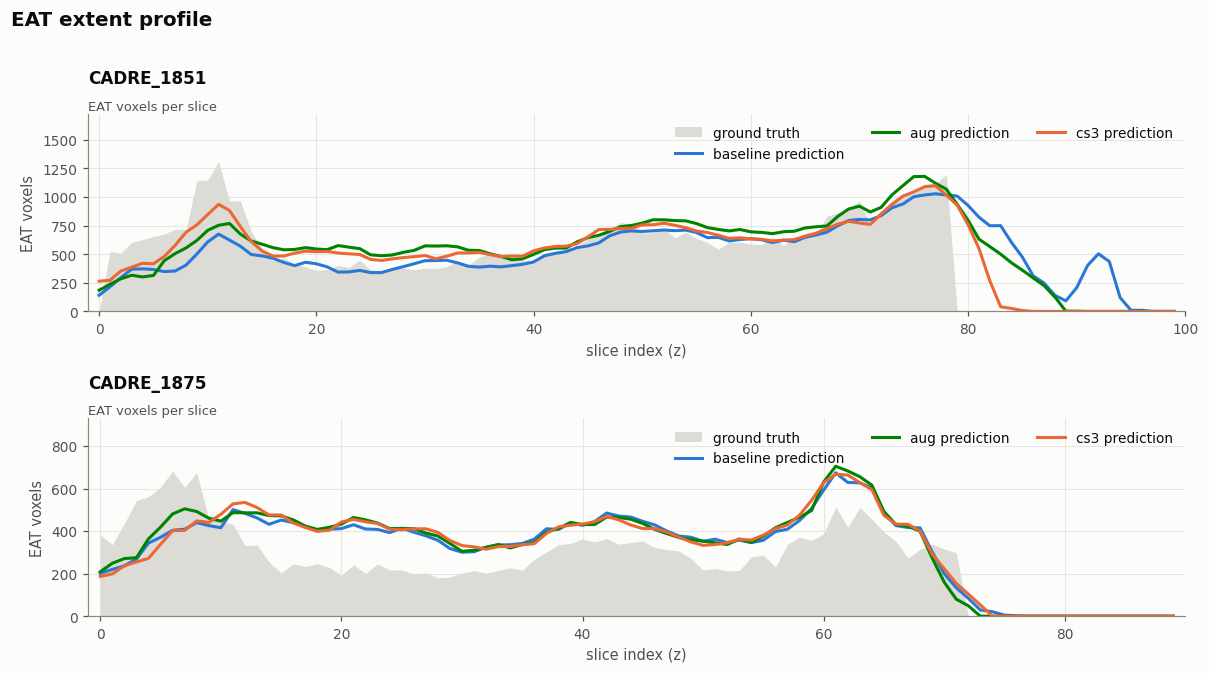

In [9]:
fig, axes = plt.subplots(len(PATIENTS), 1, figsize=(11, 3.1 * len(PATIENTS)), sharex=False)
axes = np.atleast_1d(axes)

for ax, pid in zip(axes, PATIENTS):
    z = np.arange(len(R[(pid, 'baseline')]['gt']))
    ax.fill_between(z, R[(pid, 'baseline')]['gt'], color='#dcdbd6', linewidth=0,
                    label='ground truth', zorder=1)
    for arm in ARMS:
        ax.plot(z, R[(pid, arm)]['pred'], color=ARM_COLOR[arm], linewidth=2.0,
                label=f'{arm} prediction', zorder=3)
    ax.set_ylim(0, max(R[(pid, 'baseline')]['gt'].max(),
                       *(R[(pid, a)]['pred'].max() for a in ARMS)) * 1.32)
    ax.set_xlim(-1, len(z))
    ax.set_title(pid)
    subtitle(ax, 'EAT voxels per slice')
    ax.set_xlabel('slice index (z)')
    ax.set_ylabel('EAT voxels')
    ax.legend(loc='upper right', ncol=3)

fig.suptitle('EAT extent profile', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## 2. Per-slice Dice, sized by how much that slice weighs

The line is the slice's own Dice $d_i$; the marker area is its weight $w_i$. A low point
with a tiny marker is a bad slice that barely matters; a low point with a big marker is
where the score is actually lost.

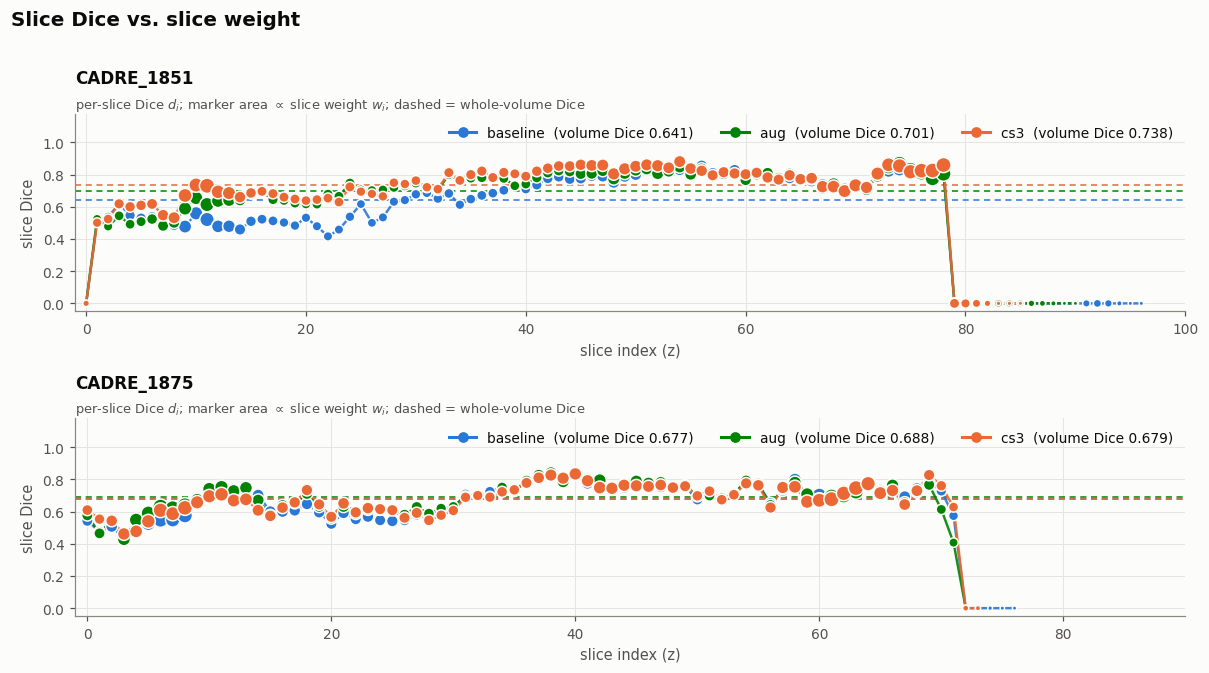

In [10]:
fig, axes = plt.subplots(len(PATIENTS), 1, figsize=(11, 3.1 * len(PATIENTS)))
axes = np.atleast_1d(axes)

for ax, pid in zip(axes, PATIENTS):
    for arm in ARMS:
        r = R[(pid, arm)]
        z = np.arange(len(r['dice_slice']))
        ax.plot(z, r['dice_slice'], color=ARM_COLOR[arm], linewidth=1.6, alpha=0.9, zorder=2)
        ax.scatter(z, r['dice_slice'], s=8 + 4200 * r['w'], color=ARM_COLOR[arm],
                   edgecolor=SURFACE, linewidth=1.0, zorder=3)
        ax.axhline(r['dice_vol'], color=ARM_COLOR[arm], linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
    ax.set_ylim(-0.05, 1.18)
    ax.set_xlim(-1, len(z))
    ax.set_title(pid)
    subtitle(ax, 'per-slice Dice $d_i$; marker area $\\propto$ slice weight $w_i$; dashed = whole-volume Dice')
    ax.set_xlabel('slice index (z)')
    ax.set_ylabel('slice Dice')
    ax.legend(handles=[Line2D([], [], color=ARM_COLOR[a], lw=2, marker='o', markersize=6,
                              label=f'{a}  (volume Dice {R[(pid, a)]["dice_vol"]:.3f})') for a in ARMS],
              loc='upper right', ncol=len(ARMS))

fig.suptitle('Slice Dice vs. slice weight', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## 3. The headline — which slices carry the deficit, and is it FP or FN?

Bar heights are $w_i(1-d_i)$, split into its false-negative (under-segmentation) and
false-positive (over-segmentation) halves. **The bars sum exactly to $1-\mathrm{Dice}$**,
so the two panels are directly comparable in absolute terms: the area removed between
baseline and cs3 *is* the Dice gained.

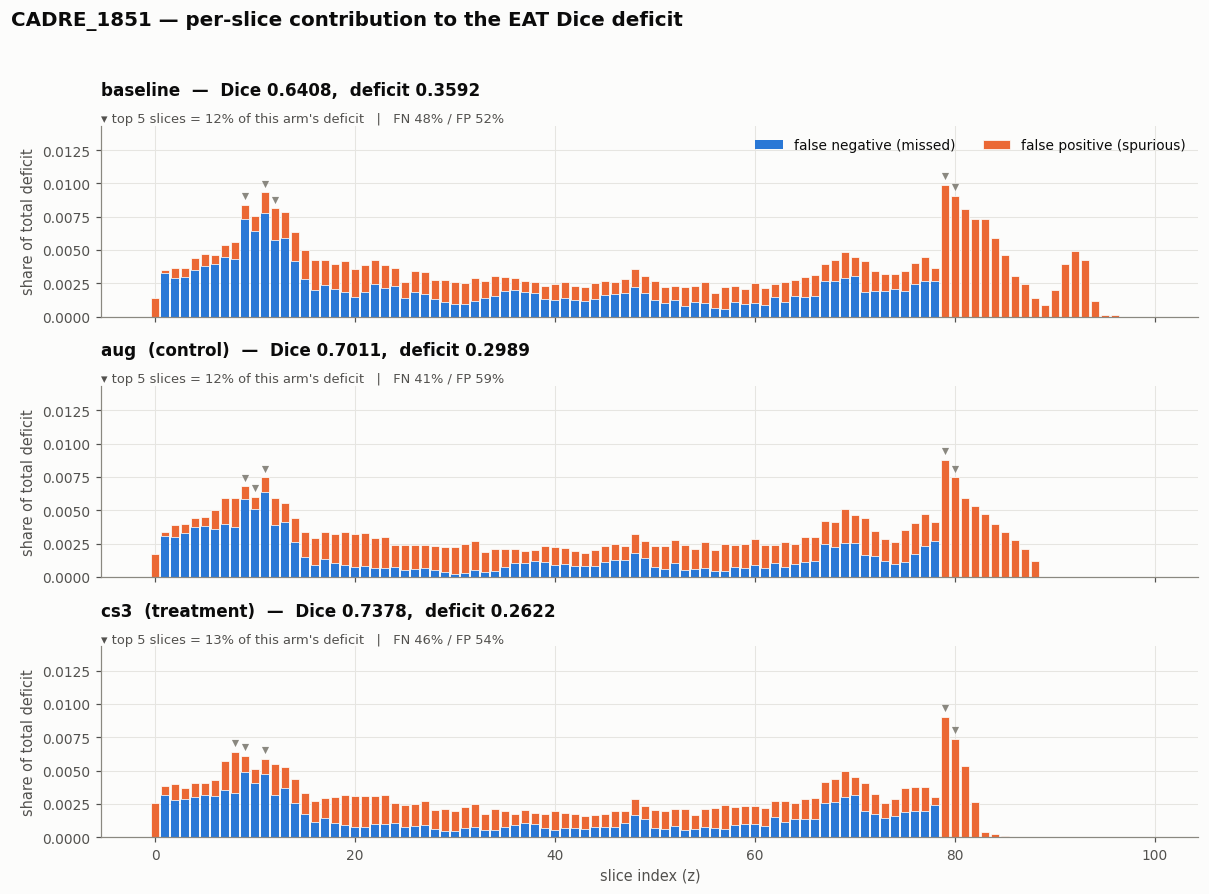

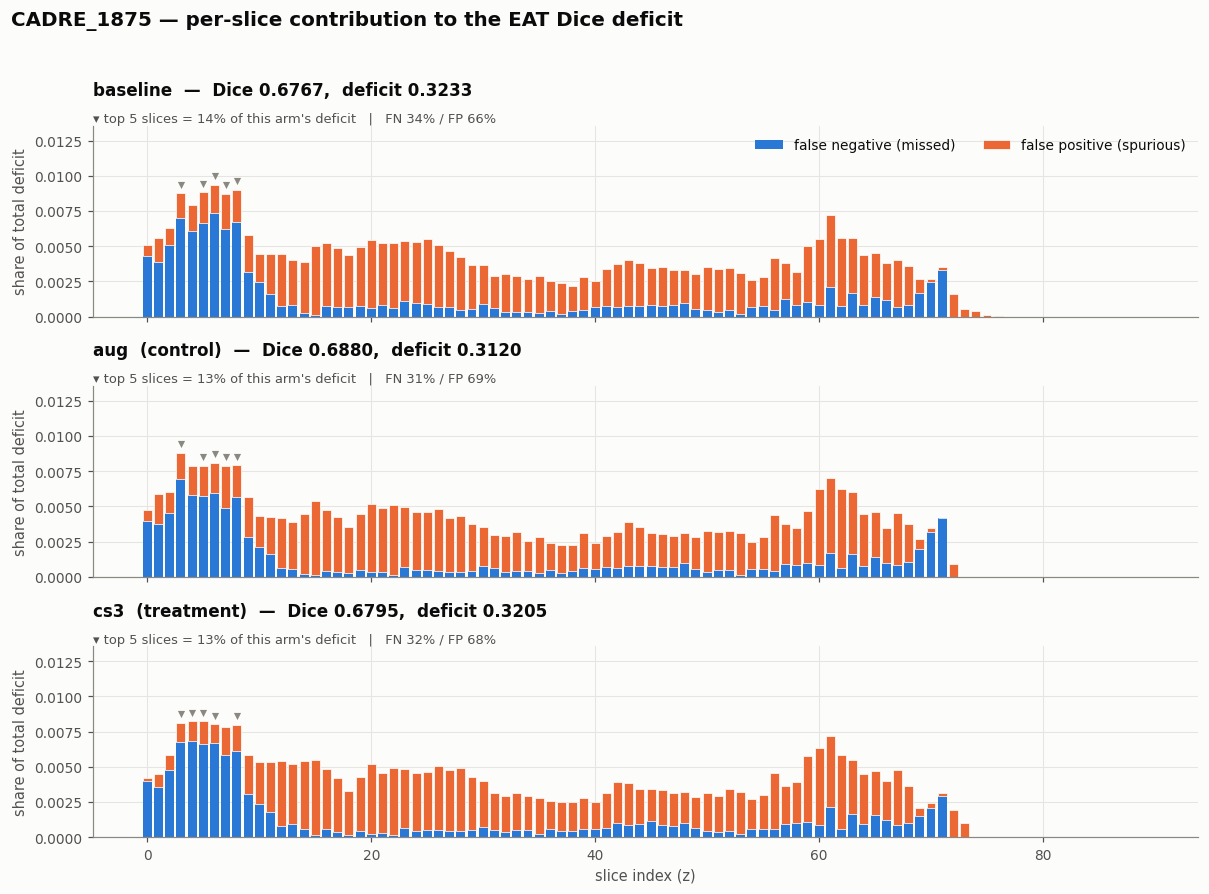

In [11]:
for pid in PATIENTS:
    n_z = len(R[(pid, CONTROL)]['deficit'])
    ymax = max(R[(pid, a)]['deficit'].max() for a in ARMS) * 1.45

    fig, axes = plt.subplots(len(ARMS), 1, figsize=(11, 2.75 * len(ARMS)),
                             sharex=True, sharey=True)
    for ax, arm in zip(np.atleast_1d(axes), ARMS):
        r = R[(pid, arm)]
        z = np.arange(n_z)
        ax.bar(z, r['deficit_fn'], width=0.8, color=FN_COLOR, linewidth=0, label='false negative (missed)')
        ax.bar(z, r['deficit_fp'], width=0.8, bottom=r['deficit_fn'], color=FP_COLOR,
               linewidth=0.5, edgecolor=SURFACE, label='false positive (spurious)')
        top = np.argsort(r['deficit'])[::-1][:5]
        ax.scatter(top, r['deficit'][top] + ymax * 0.045, marker='v', s=22,
                   color=INK_MUTED, linewidth=0, zorder=4)
        share = r['deficit'][top].sum() / r['deficit'].sum()
        tag = {CONTROL: '  (control)', TREATMENT: '  (treatment)'}.get(arm, '')
        ax.set_title(f'{arm}{tag}  —  Dice {r["dice_vol"]:.4f},  deficit {1 - r["dice_vol"]:.4f}')
        subtitle(ax, f'▾ top 5 slices = {share:.0%} of this arm\'s deficit   |   '
                     f'FN {r["deficit_fn"].sum() / r["deficit"].sum():.0%} / '
                     f'FP {r["deficit_fp"].sum() / r["deficit"].sum():.0%}')
        ax.set_ylim(0, ymax)
        ax.set_ylabel('share of total deficit')
    np.atleast_1d(axes)[0].legend(loc='upper right', ncol=2)
    np.atleast_1d(axes)[-1].set_xlabel('slice index (z)')
    fig.suptitle(f'{pid} — per-slice contribution to the EAT Dice deficit',
                 x=0.005, ha='left', fontsize=13, fontweight='semibold')
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

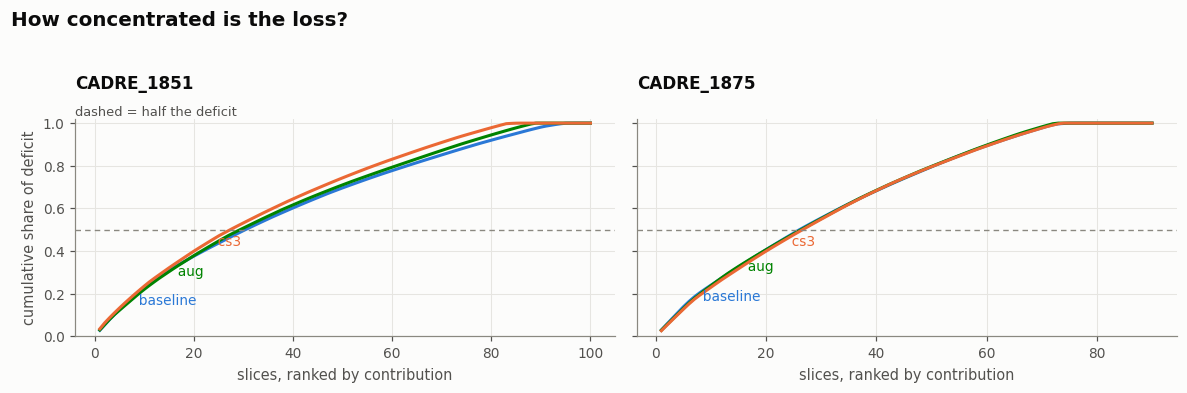

patient       arm          slices for 50% of deficit   for 80%
CADRE_1851    baseline                            31        64
CADRE_1851    aug                                 30        61
CADRE_1851    cs3                                 28        57
CADRE_1875    baseline                            27        51
CADRE_1875    aug                                 27        51
CADRE_1875    cs3                                 27        51


In [12]:
# concentration: how few slices account for how much of the deficit
fig, axes = plt.subplots(1, len(PATIENTS), figsize=(5.4 * len(PATIENTS), 3.6), sharey=True)
axes = np.atleast_1d(axes)

for ax, pid in zip(axes, PATIENTS):
    for i, arm in enumerate(ARMS):
        r = R[(pid, arm)]
        srt = np.sort(r['deficit'])[::-1]
        cum = np.cumsum(srt) / srt.sum()
        k = np.arange(1, len(cum) + 1)
        ax.plot(k, cum, color=ARM_COLOR[arm], linewidth=2.0)
        j = min(6 + 8 * i, len(cum) - 1)          # stagger labels so arms do not collide
        ax.text(k[j], cum[j], f'  {arm}', color=ARM_COLOR[arm], fontsize=9, va='center')
    ax.axhline(0.5, color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 3)))
    ax.set_title(pid)
    ax.set_xlabel('slices, ranked by contribution')
    ax.set_ylim(0, 1.02)
axes[0].set_ylabel('cumulative share of deficit')
subtitle(axes[0], 'dashed = half the deficit')
fig.suptitle('How concentrated is the loss?', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

print(f'{"patient":<14}{"arm":<10}{"slices for 50% of deficit":>28}{"for 80%":>10}')
for pid in PATIENTS:
    for arm in ARMS:
        cum = np.cumsum(np.sort(R[(pid, arm)]['deficit'])[::-1]); cum /= cum[-1]
        print(f'{pid:<14}{arm:<10}{int(np.searchsorted(cum, 0.5)) + 1:>28}{int(np.searchsorted(cum, 0.8)) + 1:>10}')

## 4. *Why* — what the errors actually are

Two questions the location alone cannot answer:

- **What is EAT being confused with?** For every false-positive EAT voxel, what does the
  ground truth say it is; for every false negative, what did the model call it instead.
- **Rim or region?** Error voxels touching a correctly-predicted EAT voxel are boundary
  jitter on a thin, diffuse structure — largely irreducible, given EAT's perimeter-to-volume
  ratio. Errors away from any correct EAT are missed regions and hallucinations: the
  genuinely fixable part.

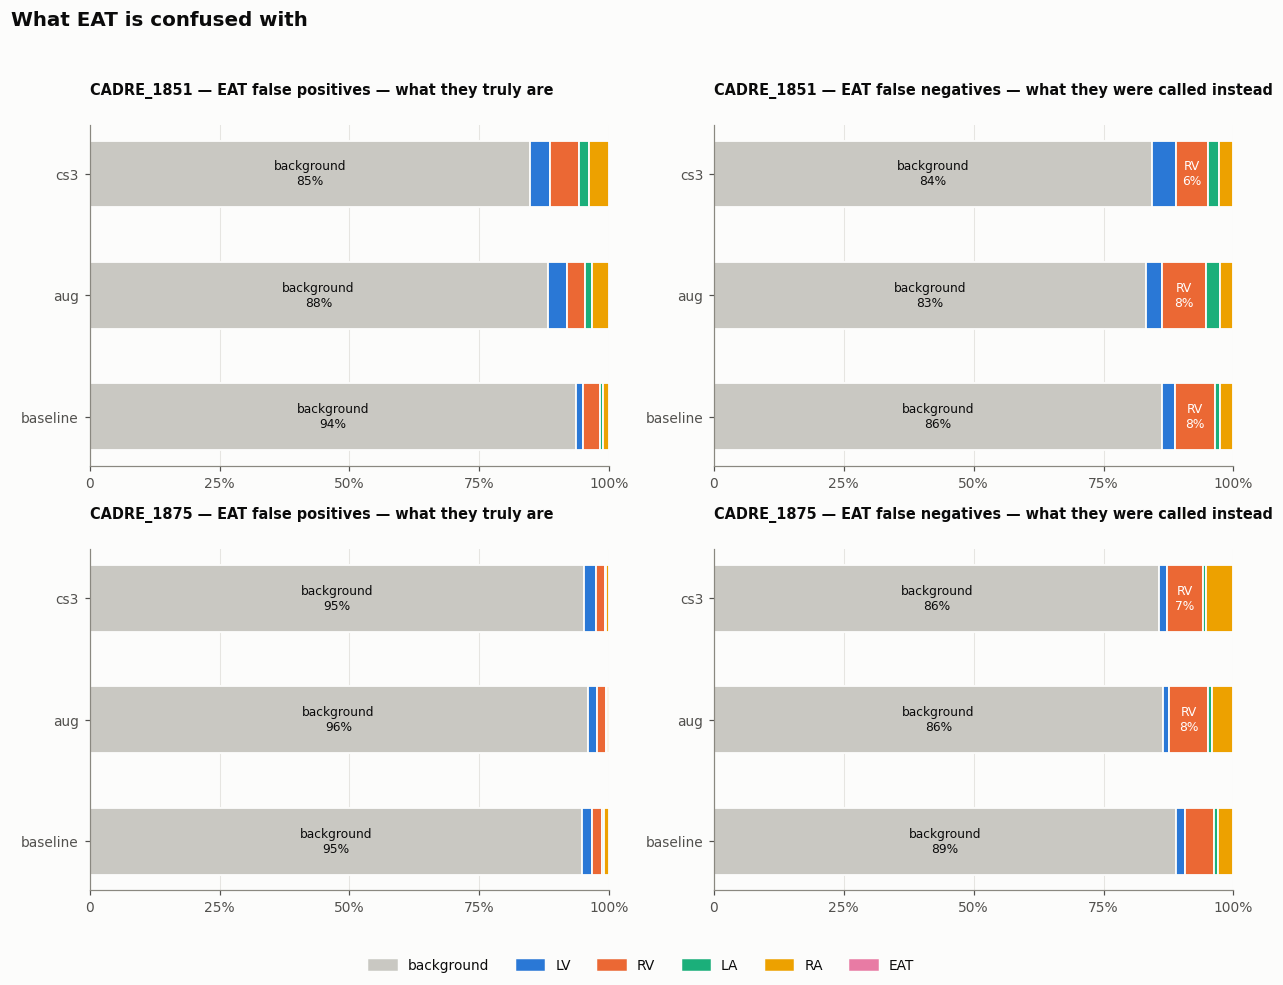

patient     arm       error  background          LV          RV          LA          RA         EAT
1851        baseline  FP         93.6%       1.4%       3.3%       0.7%       1.1%       0.0%
1851        baseline  FN         86.2%       2.5%       7.8%       0.9%       2.6%       0.0%
1851        aug       FP         88.1%       3.8%       3.4%       1.3%       3.3%       0.0%
1851        aug       FN         83.1%       3.1%       8.5%       2.8%       2.5%       0.0%
1851        cs3       FP         84.7%       3.9%       5.6%       1.8%       3.9%       0.0%
1851        cs3       FN         84.3%       4.5%       6.2%       2.2%       2.7%       0.0%
1875        baseline  FP         94.7%       1.9%       2.0%       0.4%       1.0%       0.0%
1875        baseline  FN         89.0%       1.6%       5.7%       0.7%       3.0%       0.0%
1875        aug       FP         95.8%       1.9%       1.7%       0.2%       0.4%       0.0%
1875        aug       FN         86.4%       1.2%     

In [13]:
LABEL_COLOR = {0: '#c9c8c2', 1: C_BLUE, 2: C_ORANGE, 3: C_AQUA, 4: C_YELLOW, 5: C_MAGENTA}

fig, axes = plt.subplots(len(PATIENTS), 2, figsize=(11.5, 1.5 * len(ARMS) * len(PATIENTS)))
axes = np.atleast_2d(axes)

for row, pid in zip(axes, PATIENTS):
    for ax, (key, title) in zip(row, [('fp_true_label', 'EAT false positives — what they truly are'),
                                      ('fn_pred_label', 'EAT false negatives — what they were called instead')]):
        arms = list(ARMS)
        for y, arm in enumerate(arms):
            v = R[(pid, arm)]['attribution'][key]
            v = v / max(v.sum(), 1)
            left = 0.0
            for cls in range(len(v)):
                if v[cls] <= 0:
                    continue
                ax.barh(y, v[cls], left=left, height=0.55, color=LABEL_COLOR[cls],
                        edgecolor=SURFACE, linewidth=1.2)
                if v[cls] > 0.06:
                    ax.text(left + v[cls] / 2, y, f'{CLASS_LBL[cls]}\n{v[cls]:.0%}', ha='center',
                            va='center', fontsize=8, color=INK if cls in (0, 4) else 'white')
                left += v[cls]
        ax.set_yticks(range(len(arms)), arms)
        ax.set_xlim(0, 1); ax.set_xticks([0, .25, .5, .75, 1], ['0', '25%', '50%', '75%', '100%'])
        ax.grid(axis='y', visible=False)
        ax.set_title(f'{pid} — {title}', fontsize=9.5)

fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=LABEL_COLOR[c], label=CLASS_LBL[c])
                    for c in range(len(CLASS_LBL))],
           loc='lower center', ncol=len(CLASS_LBL), frameon=False, fontsize=9)
fig.suptitle('What EAT is confused with', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0.05, 1, 0.96))
plt.show()

# table view -- the stacks are dominated by one category and three fills sit under 3:1 on the surface
print(f'{"patient":<12}{"arm":<10}{"error":<5}' + ''.join(f'{CLASS_LBL[c]:>12}' for c in range(len(CLASS_LBL))))
for pid in PATIENTS:
    for arm in ARMS:
        for key, tag in [('fp_true_label', 'FP'), ('fn_pred_label', 'FN')]:
            v = R[(pid, arm)]['attribution'][key]; v = v / max(v.sum(), 1)
            print(f'{pid.replace("CADRE_", ""):<12}{arm:<10}{tag:<5}' + ''.join(f'{x:>11.1%}' for x in v))

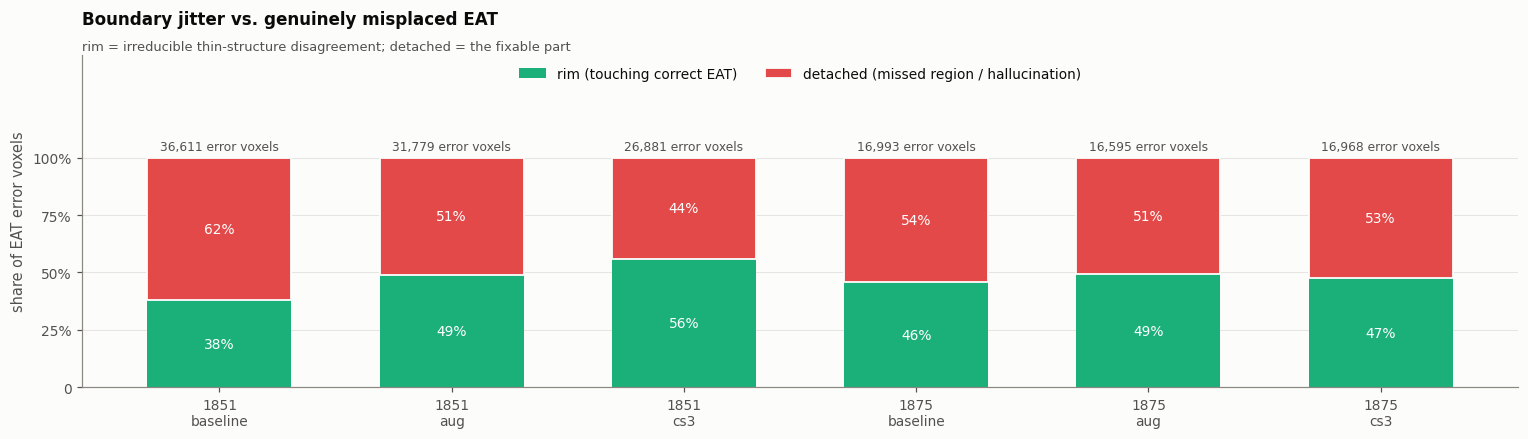

In [14]:
fig, ax = plt.subplots(figsize=(2.0 * len(PATIENTS) * len(ARMS) + 2.0, 4.1))
labels, rim_share, det_share, ticks = [], [], [], []
for pid in PATIENTS:
    for arm in ARMS:
        r = R[(pid, arm)]['rim']
        labels.append(f'{pid.replace("CADRE_", "")}\n{arm}')
        rim_share.append(r['rim'] / r['total'])
        det_share.append(r['detached'] / r['total'])
        ticks.append(r['total'])

x = np.arange(len(labels))
ax.bar(x, rim_share, width=0.62, color=C_AQUA, linewidth=0, label='rim (touching correct EAT)')
ax.bar(x, det_share, width=0.62, bottom=rim_share, color=C_RED, edgecolor=SURFACE,
       linewidth=1.2, label='detached (missed region / hallucination)')
for xi, (rm, d, tot) in enumerate(zip(rim_share, det_share, ticks)):
    ax.text(xi, rm / 2, f'{rm:.0%}', ha='center', va='center', fontsize=9, color='white')
    ax.text(xi, rm + d / 2, f'{d:.0%}', ha='center', va='center', fontsize=9, color='white')
    ax.text(xi, 1.02, f'{tot:,} error voxels', ha='center', va='bottom', fontsize=8, color=INK_2)
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.45); ax.set_yticks([0, .25, .5, .75, 1], ['0', '25%', '50%', '75%', '100%'])
ax.set_ylabel('share of EAT error voxels')
ax.grid(axis='x', visible=False)
ax.legend(loc='upper center', ncol=2)
ax.set_title('Boundary jitter vs. genuinely misplaced EAT')
subtitle(ax, 'rim = irreducible thin-structure disagreement; detached = the fixable part')
fig.tight_layout()
plt.show()

## 5. The worst slices, rendered

For each arm, the three slices contributing most to that arm's deficit: water image with
ground-truth (blue) and predicted (orange) EAT contours, and the model's per-pixel
prediction entropy. Confident errors and uncertain errors call for different fixes.

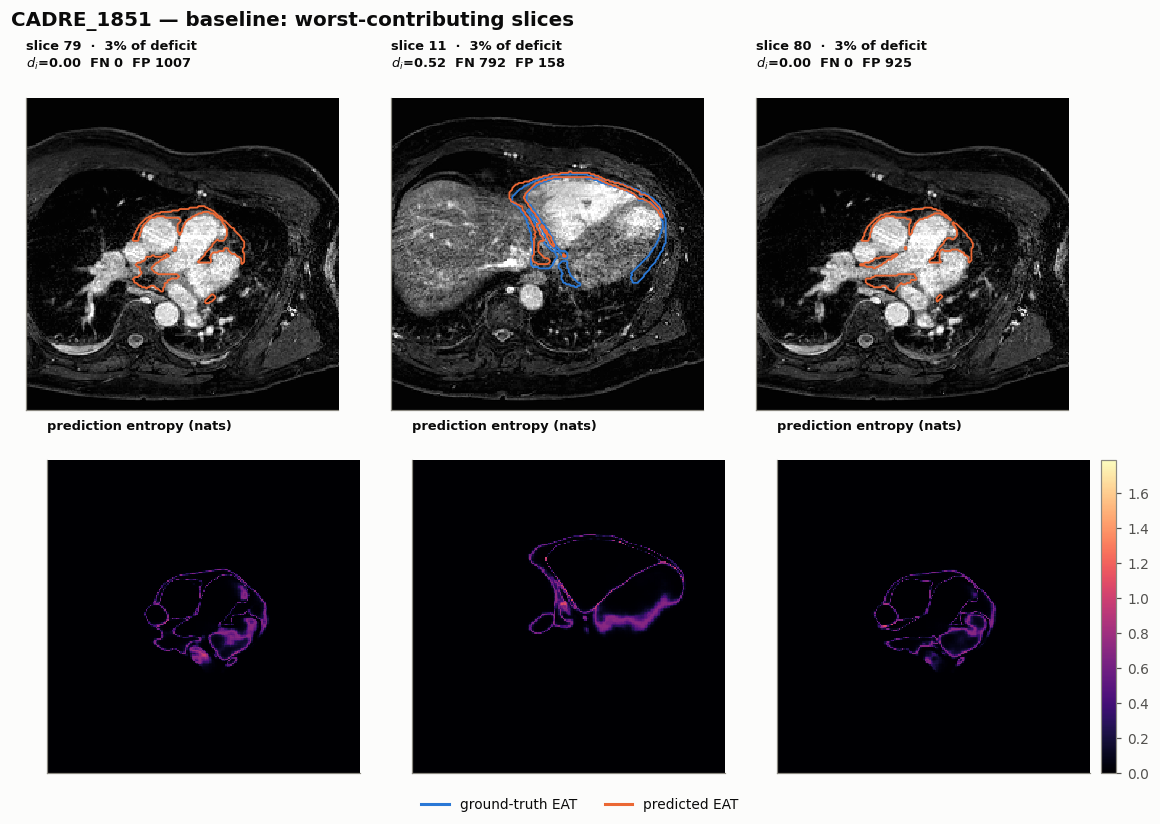

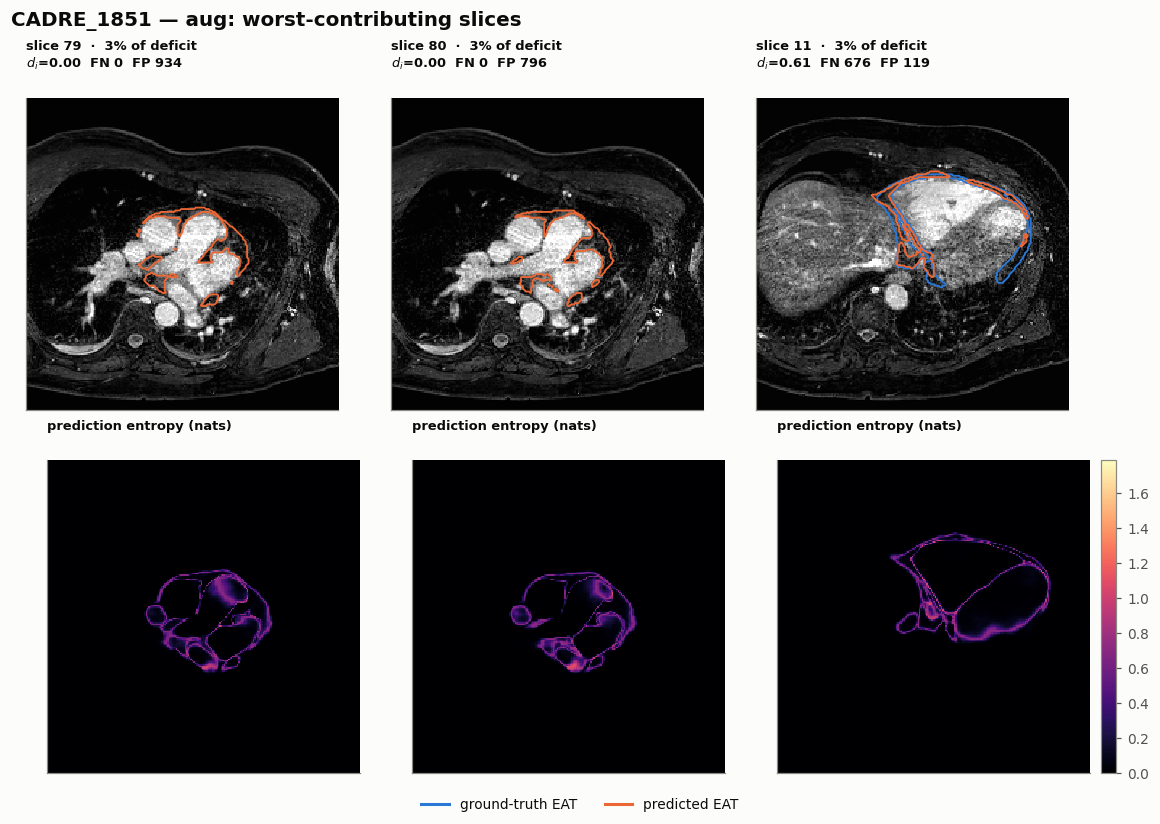

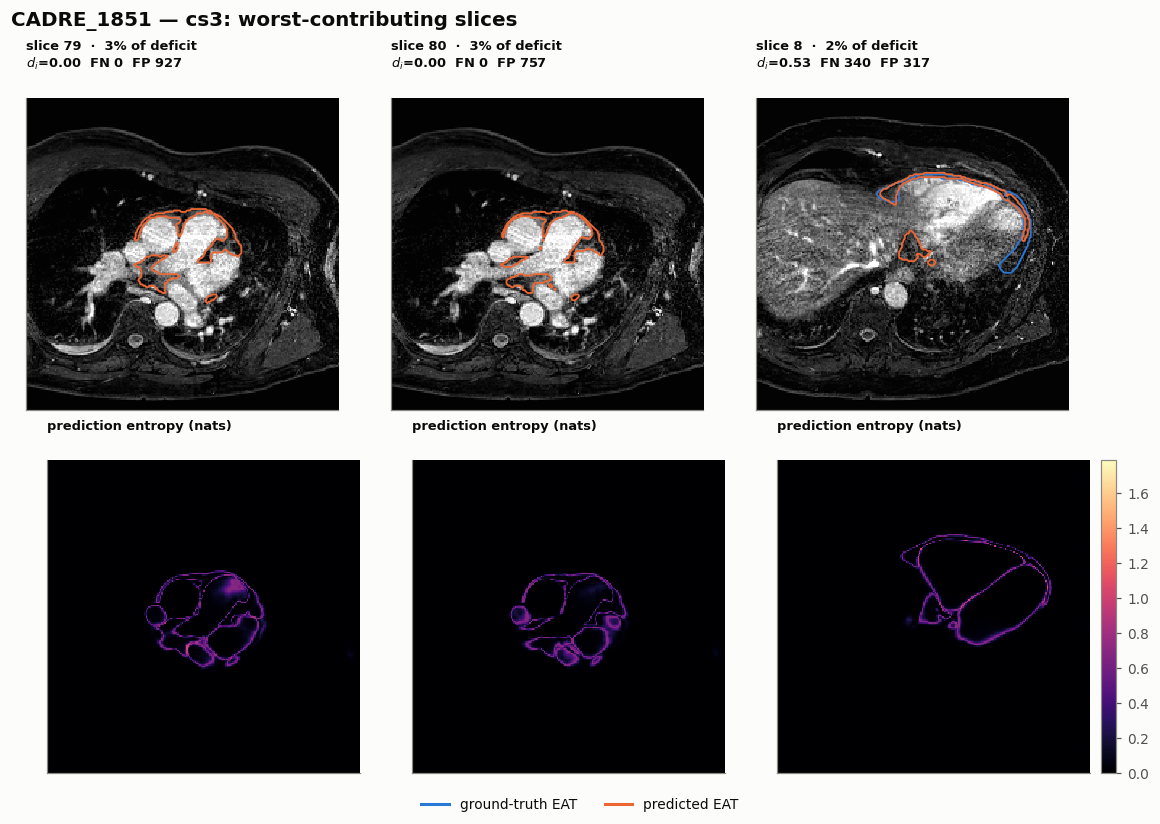

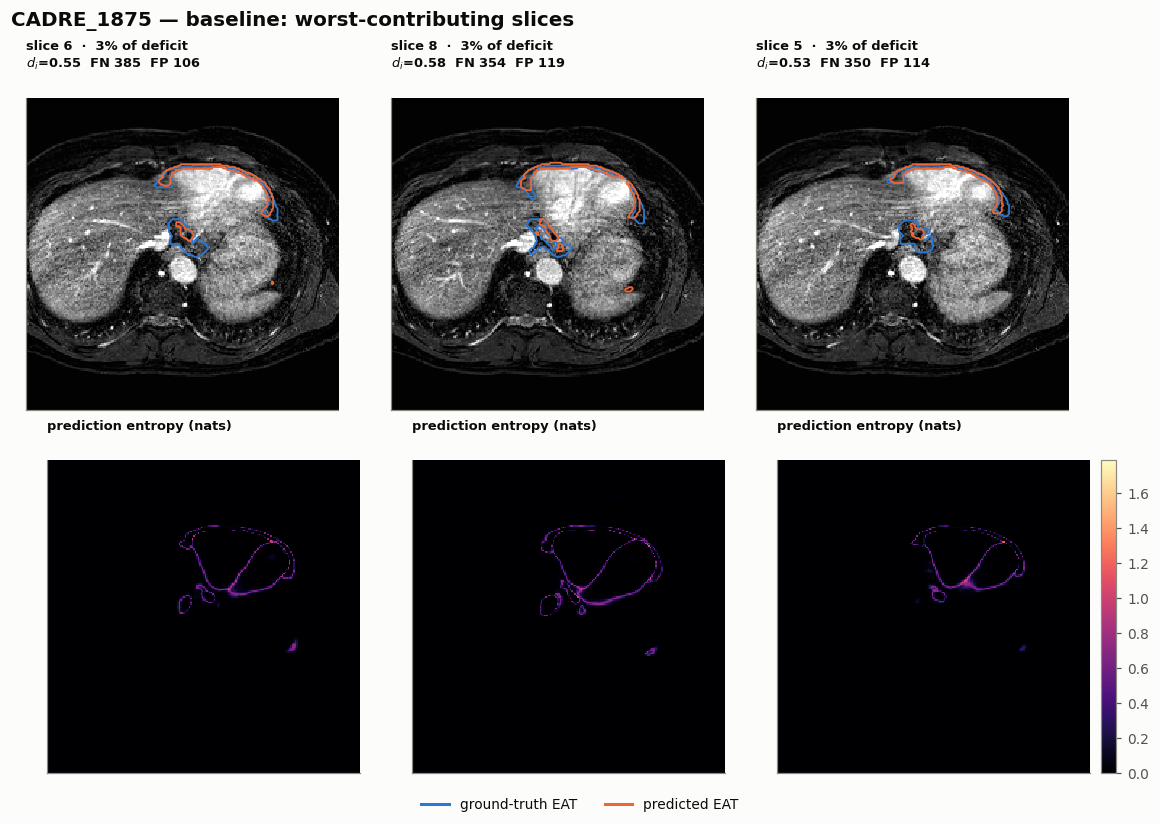

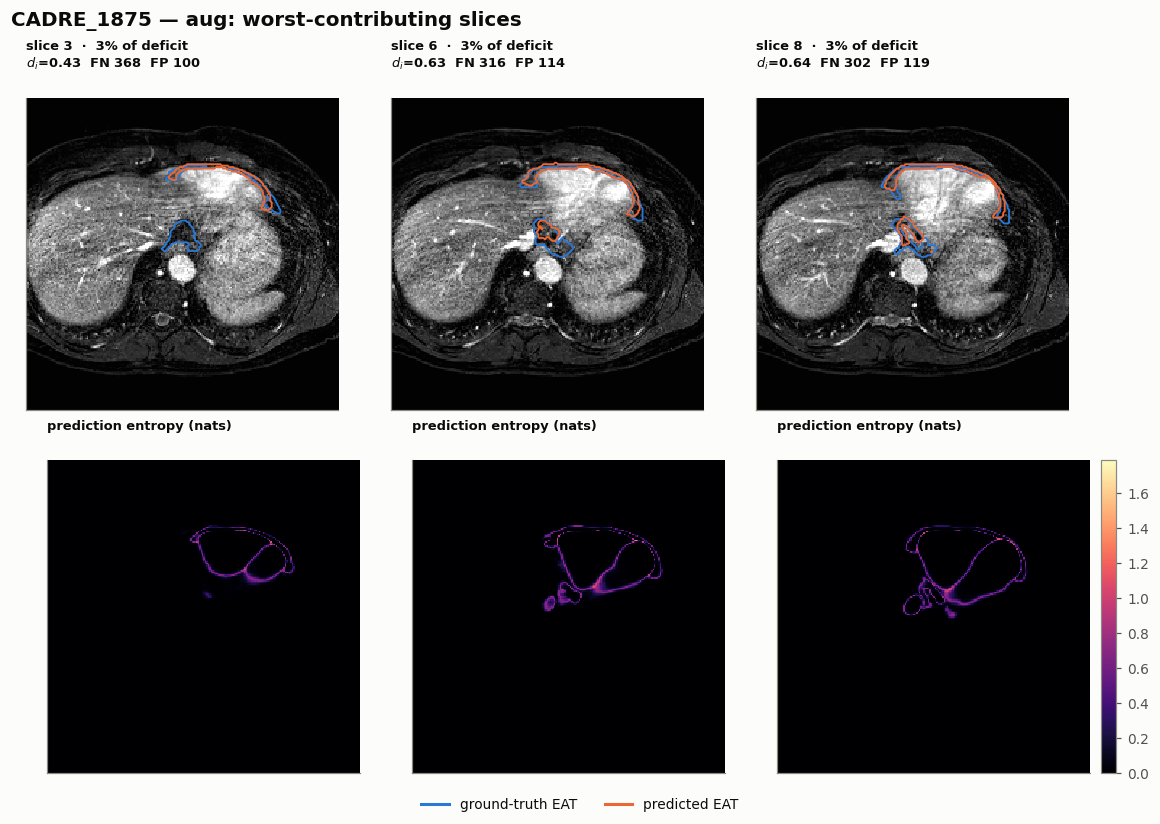

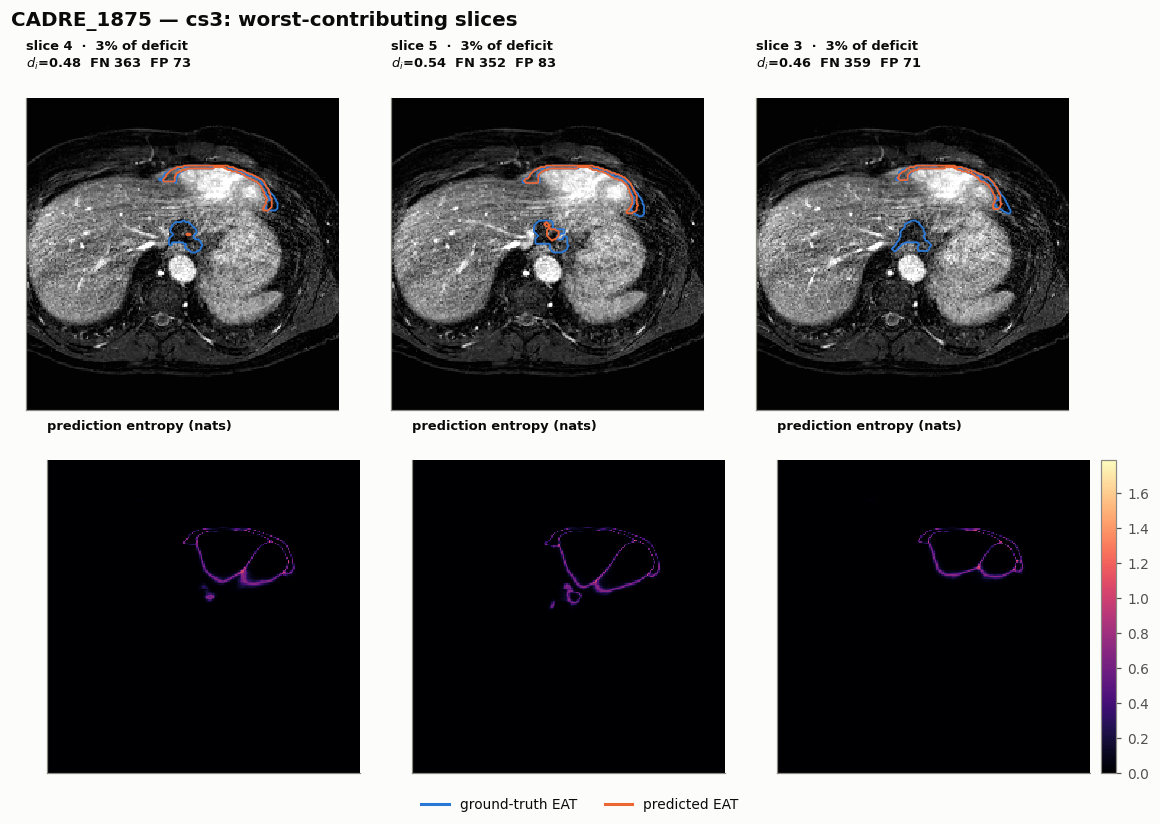

In [15]:
def center_water(rec, k):
    # water channel of the centre slice (channels are water-window then fat-window)
    img = rec['dataset'][rec['indices'][k]]['image'].numpy()
    window = 2 * rec['cfg']['context_slices'] + 1
    return img[window // 2]

for pid in PATIENTS:
    for arm in ARMS:
        r = R[(pid, arm)]
        worst = np.argsort(r['deficit'])[::-1][:3]
        fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.4), layout='constrained')
        for col, k in enumerate(worst):
            img = center_water(r, int(k))
            gt, pr = r['gt_vol'][k] == EAT_CLS, r['pred_vol'][k] == EAT_CLS

            ax = axes[0, col]
            ax.imshow(img, cmap='gray', interpolation='nearest')
            if gt.any(): ax.contour(gt, levels=[0.5], colors=[C_BLUE], linewidths=1.2)
            if pr.any(): ax.contour(pr, levels=[0.5], colors=[C_ORANGE], linewidths=1.2)
            ax.set_title(f'slice {k}  ·  {r["deficit"][k] / r["deficit"].sum():.0%} of deficit\n'
                         f'$d_i$={r["dice_slice"][k]:.2f}  FN {int(r["fn"][k])}  FP {int(r["fp"][k])}',
                         fontsize=8.5)

            ax = axes[1, col]
            im = ax.imshow(r['entropy'][k], cmap='magma', interpolation='nearest',
                           vmin=0, vmax=np.log(r['cfg']['n_classes']))
            ax.set_title('prediction entropy (nats)', fontsize=8.5)
        for ax in axes.ravel():
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        fig.colorbar(im, ax=axes[1, :], fraction=0.03, pad=0.01)
        fig.legend(handles=[Line2D([], [], color=C_BLUE, lw=2, label='ground-truth EAT'),
                            Line2D([], [], color=C_ORANGE, lw=2, label='predicted EAT')],
                   loc='outside lower center', ncol=2, frameon=False)
        fig.suptitle(f'{pid} — {arm}: worst-contributing slices',
                     x=0.01, ha='left', fontsize=13, fontweight='semibold')
        plt.show()

## 6. Summary table

Everything above, as numbers.

In [16]:
print(f'{"patient":<12}{"arm":<10}{"dice":>8}{"deficit":>9}{"FN%":>6}{"FP%":>6}'
      f'{"n50":>5}{"n80":>5}{"detached%":>11}{"top-5 share":>13}')
for pid in PATIENTS:
    for arm in ARMS:
        r = R[(pid, arm)]
        dfc = r['deficit']; cum = np.cumsum(np.sort(dfc)[::-1]) / dfc.sum()
        print(f'{pid.replace("CADRE_", ""):<12}{arm:<10}{r["dice_vol"]:>8.4f}{dfc.sum():>9.4f}'
              f'{100 * r["deficit_fn"].sum() / dfc.sum():>6.0f}{100 * r["deficit_fp"].sum() / dfc.sum():>6.0f}'
              f'{int(np.searchsorted(cum, .5)) + 1:>5}{int(np.searchsorted(cum, .8)) + 1:>5}'
              f'{100 * r["rim"]["detached"] / r["rim"]["total"]:>11.0f}'
              f'{np.sort(dfc)[::-1][:5].sum() / dfc.sum():>13.0%}')
print('\nn50 / n80 = number of slices accounting for 50% / 80% of that arm\'s Dice deficit.')

patient     arm           dice  deficit   FN%   FP%  n50  n80  detached%  top-5 share
1851        baseline    0.6408   0.3592    48    52   31   64         62          12%
1851        aug         0.7011   0.2989    41    59   30   61         51          12%
1851        cs3         0.7378   0.2622    46    54   28   57         44          13%
1875        baseline    0.6767   0.3233    34    66   27   51         54          14%
1875        aug         0.6880   0.3120    31    69   27   51         51          13%
1875        cs3         0.6795   0.3205    32    68   27   51         53          13%

n50 / n80 = number of slices accounting for 50% / 80% of that arm's Dice deficit.
